In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
#Метрики
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support
)


#Загрузка данных

In [4]:
data = pd.read_csv('train.csv')

#Отображение первых нескольких строк
print(data.head())

#Отображение информации о данных
print(data.info())

   ClientPeriod  MonthlySpending TotalSpent     Sex  IsSeniorCitizen  \
0            55            19.50    1026.35    Male                0   
1            72            25.85     1872.2    Male                0   
2             1            75.90       75.9    Male                0   
3            32            79.30       2570  Female                1   
4            60           115.25    6758.45  Female                0   

  HasPartner HasChild HasPhoneService HasMultiplePhoneNumbers  \
0        Yes      Yes             Yes                      No   
1        Yes       No             Yes                     Yes   
2         No       No             Yes                      No   
3        Yes       No             Yes                     Yes   
4        Yes      Yes             Yes                     Yes   

  HasInternetService HasOnlineSecurityService      HasOnlineBackup  \
0                 No      No internet service  No internet service   
1                 No      No interne

In [5]:
print(f"Duplicated rows: {data.duplicated(keep=False).sum()}")
print(f"Duplicated rows without target: {data.drop('Churn', axis=1).duplicated(keep=False).sum()}")

Duplicated rows: 28
Duplicated rows without target: 41


In [6]:
data = data.drop_duplicates()

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5268 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5268 non-null   int64  
 1   MonthlySpending           5268 non-null   float64
 2   TotalSpent                5268 non-null   object 
 3   Sex                       5268 non-null   object 
 4   IsSeniorCitizen           5268 non-null   int64  
 5   HasPartner                5268 non-null   object 
 6   HasChild                  5268 non-null   object 
 7   HasPhoneService           5268 non-null   object 
 8   HasMultiplePhoneNumbers   5268 non-null   object 
 9   HasInternetService        5268 non-null   object 
 10  HasOnlineSecurityService  5268 non-null   object 
 11  HasOnlineBackup           5268 non-null   object 
 12  HasDeviceProtection       5268 non-null   object 
 13  HasTechSupportAccess      5268 non-null   object 
 14  HasOnlineTV  

In [18]:
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')
missing = data.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 0


In [9]:
data['TotalSpent'] = data['TotalSpent'].fillna(0)
missing = data.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 0


#Кодирование категориальных переменных 

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']

for col in binary_cols:
    data[col] = le.fit_transform(data[col])

le.fit_transform(data['HasChild'])[:10]

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

Удаляем признаки, не вляющие на предсказание

In [28]:
data.drop(['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsSeniorCitizen'], axis =1)

,ClientPeriod,MonthlySpending,TotalSpent,IsBillingPaperless,Churn,HasMultiplePhoneNumbers_No phone service,HasMultiplePhoneNumbers_Yes,HasInternetService_Fiber optic,HasInternetService_No,HasOnlineSecurityService_No internet service,...,HasTechSupportAccess_Yes,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,0,0,0,0,0,1,1,...,0,1,0,1,0,1,0,0,0,1
1,72,25.85,1872.20,0,0,0,1,0,1,1,...,0,1,0,1,0,0,1,1,0,0
2,1,75.90,75.90,1,1,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,32,79.30,2570.00,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60,115.25,6758.45,0,0,0,1,1,0,0,...,1,0,1,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
5278,50,44.45,2188.45,1,0,1,0,0,0,0,...,1,0,1,0,0,1,0,0,0,0
5279,1,55.05,55.05,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
5280,29,76.00,2215.25,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5268 entries, 0 to 5281
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ClientPeriod                                  5268 non-null   int64  
 1   MonthlySpending                               5268 non-null   float64
 2   TotalSpent                                    5268 non-null   float64
 3   Sex                                           5268 non-null   int64  
 4   IsSeniorCitizen                               5268 non-null   int64  
 5   HasPartner                                    5268 non-null   int64  
 6   HasChild                                      5268 non-null   int64  
 7   HasPhoneService                               5268 non-null   int64  
 8   IsBillingPaperless                            5268 non-null   int64  
 9   Churn                                         5268 non-null   int64 

In [30]:
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]

data = pd.get_dummies(data, columns=multi_cols, drop_first=True, dtype=int)
data.info()

KeyError: "None of [Index(['HasMultiplePhoneNumbers', 'HasInternetService',\n       'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection',\n       'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription',\n       'HasContractPhone', 'PaymentMethod'],\n      dtype='object')] are in the [columns]"

# Обучение моделей

In [113]:
X = data.drop(['Churn'], axis =1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#Масштабирование данных

In [114]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])
X_test_scaled = scaler.transform(X_test[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])


print('Первый признак ДО масштабирования:')
print(f' mean={X_train.iloc[:,0].mean():.4f}, std={X_train.iloc[:,0].std():.4f}')
print("\nПервый признак ПОСЛЕ масштабирования:")
print(f"  mean={X_train_scaled[:, 0].mean():.4f}, std={X_train_scaled[:, 0].std():.4f}")

Первый признак ДО масштабирования:
 mean=32.4680, std=24.5045

Первый признак ПОСЛЕ масштабирования:
  mean=0.0000, std=1.0000


In [115]:
# Столбцы, которые были стандартизированы
scaled_cols = ['TotalSpent',  'ClientPeriod', 'MonthlySpending']

# Превращаем scaled массив обратно в DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=scaled_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=scaled_cols, index=X_test.index)
# Остальные столбцы (0/1) из X_train
X_train_rest = X_train.drop(scaled_cols, axis=1)
X_test_rest = X_test.drop(scaled_cols, axis=1)
# Объединяем
X_train_final = pd.concat([X_train_scaled_df, X_train_rest], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_rest], axis=1)

#Обучение базовой модели (модель №1, RF)

In [90]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300,
                           criterion='gini',
                           max_depth=8,
                           min_samples_leaf=20, 
                           random_state=42, 
                           bootstrap=True,
                           max_features='sqrt',
                           class_weight='balanced')
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)

print('Истинные метки(первые 10):         ', list(y_test[:10]))
print('Randomn forest  :                  ', list(y_pred_rf[:10]))

f1_score(y_test, y_pred_rf)
print(f"F1 score: {f1_score(y_test, y_pred_rf):.4f}")




Истинные метки(первые 10):          [0, 0, 1, 1, 1, 0, 0, 0, 0, 0]
Randomn forest  :                   [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
F1 score: 0.6266


In [91]:
proba_rf = rf.predict_proba(X_test_final)

In [92]:
roc_value = roc_auc_score(y_test, proba_rf[:, 1])
print(f"ROC AUC: {roc_value:.4f}")

ROC AUC: 0.8459


#Пробуем улучшать

Параметры после GridSearch :
                           n_estimators=300,
                           criterion='gini',
                           max_depth=8,
                           min_samples_leaf=20, 
                           random_state=42, 
                           bootstrap=True,
                           max_features='sqrt'
                *ROC_AUC = 0,8456*             
после добавление параметра class_weight='balanced' -- *ROC_AUC = 0,8459*  
оставила признаки  с Gini-Importance>0.010 -- *ROC_AUC = 0,8460*
Параметры после RandomnSearch : 
                            'max_depth': 6,
                            'min_samples_leaf': 21, 
                            'n_estimators': 260
                            *ROC_AUC = 0,8454*  
                             


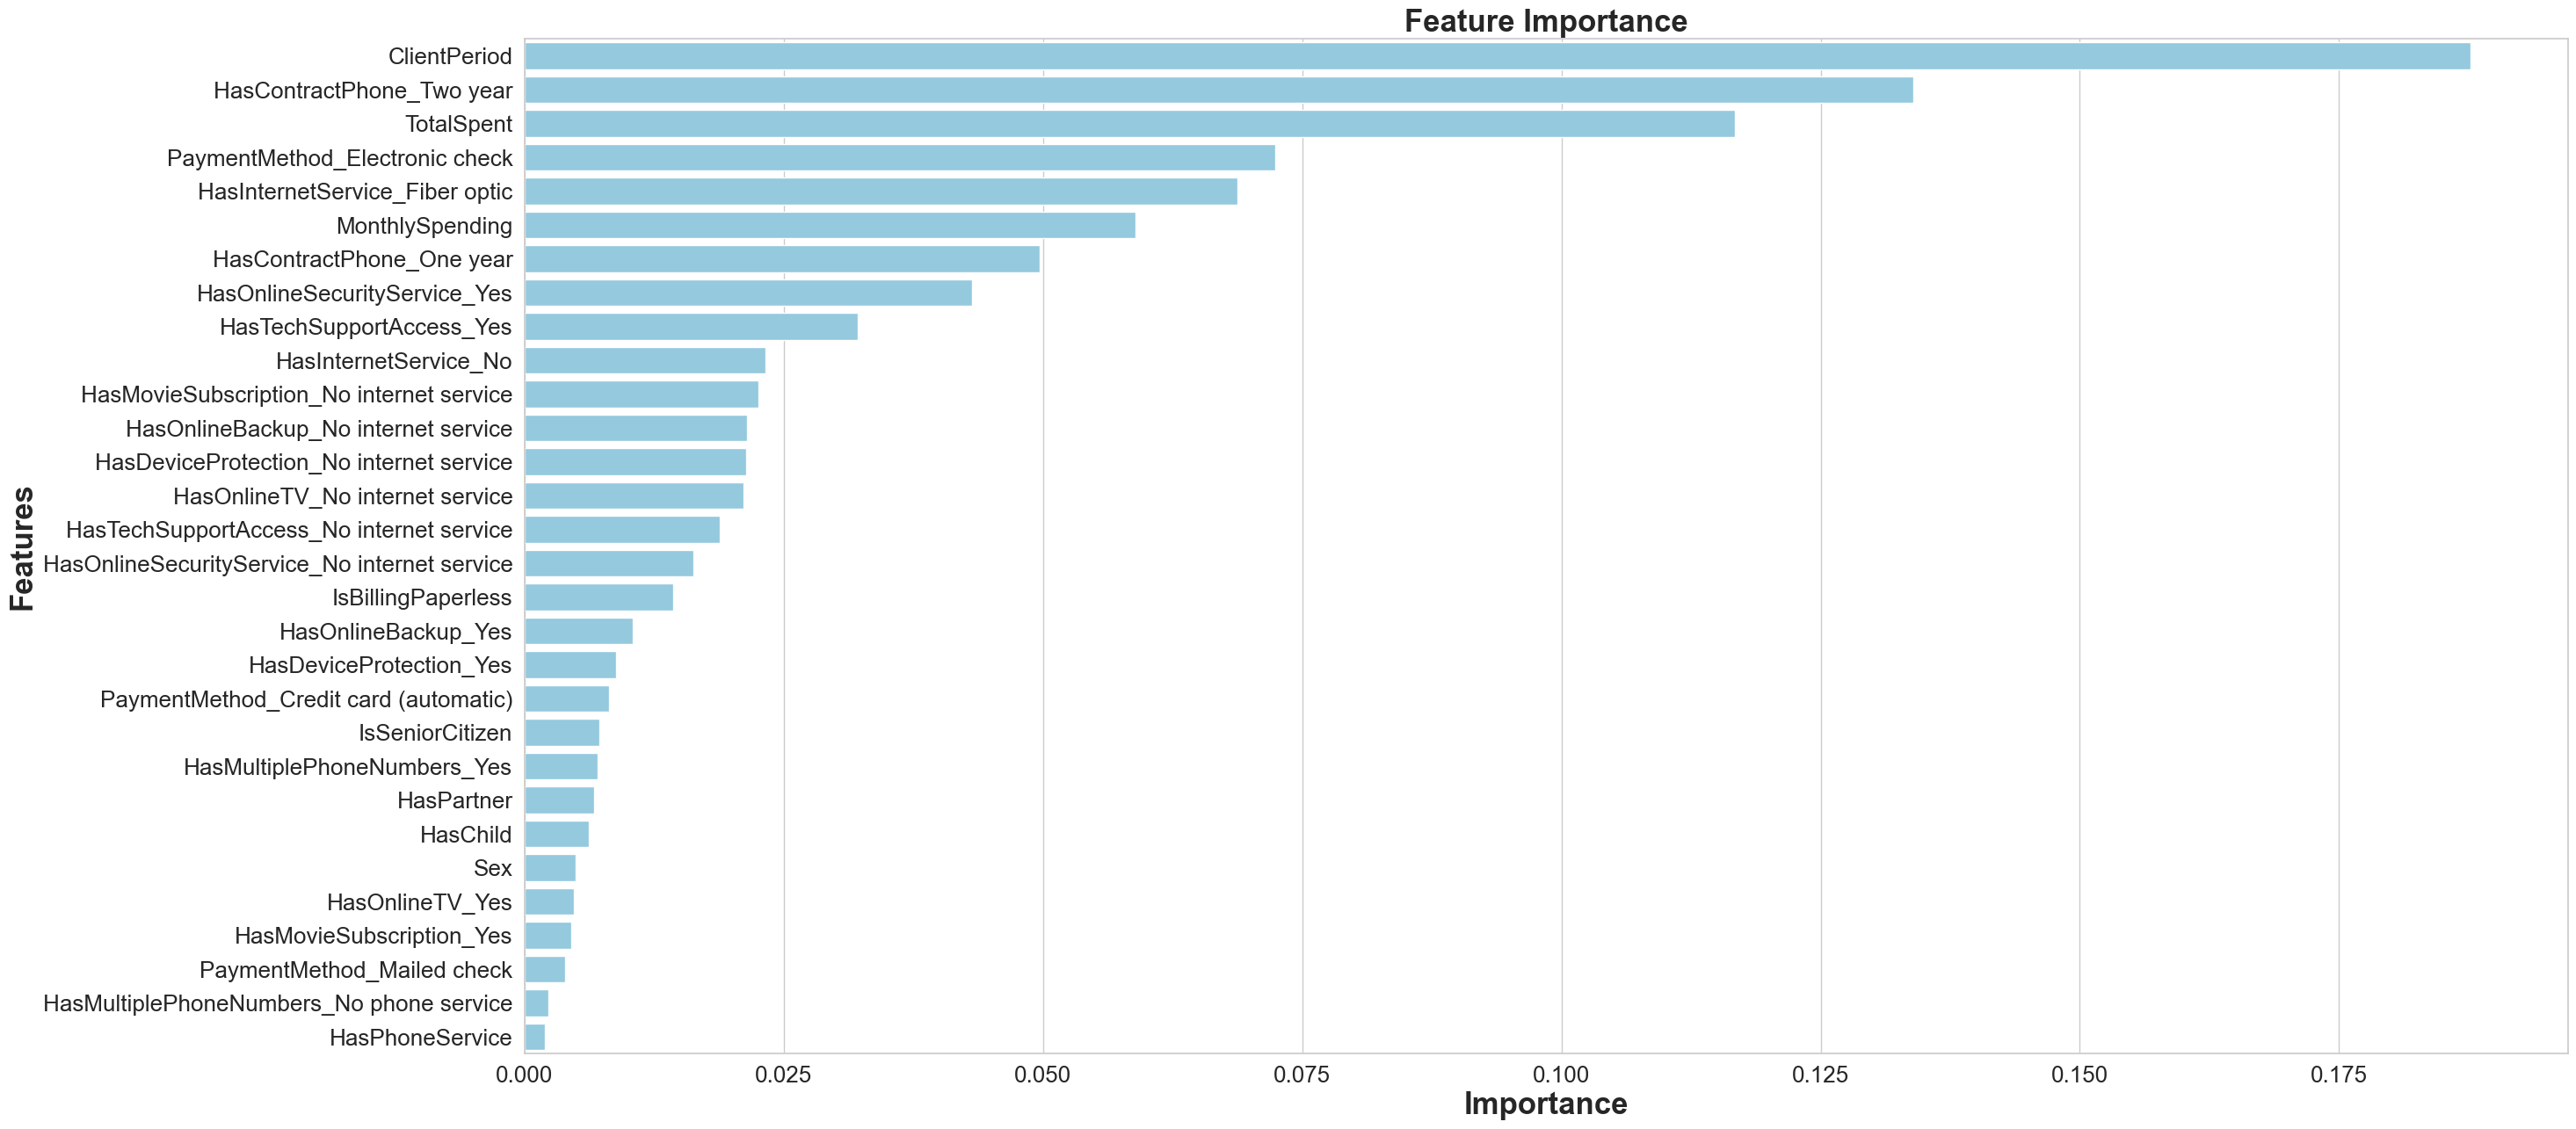

None

,Features,Gini-Importance
0,ClientPeriod,0.187665
1,HasContractPhone_Two year,0.133925
2,TotalSpent,0.116761
3,PaymentMethod_Electronic check,0.072433
4,HasInternetService_Fiber optic,0.068804
5,MonthlySpending,0.058943
6,HasContractPhone_One year,0.049681
7,HasOnlineSecurityService_Yes,0.043146
8,HasTechSupportAccess_Yes,0.032130
9,HasInternetService_No,0.023235


In [73]:
feats = {}
for feature, importance in zip(X_train_final.columns, rf.feature_importances_):
    feats[feature] = importance
importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-Importance'})
importances = importances.sort_values(by='Gini-Importance', ascending=False)
importances = importances.reset_index()
importances = importances.rename(columns={'index': 'Features'})
sns.set(font_scale = 5)
sns.set(style="whitegrid", color_codes=True, font_scale = 1.7)
fig, ax = plt.subplots()
fig.set_size_inches(30,15)
sns.barplot(x=importances['Gini-Importance'], y=importances['Features'], data=importances, color='skyblue')
plt.xlabel('Importance', fontsize=25, weight = 'bold')
plt.ylabel('Features', fontsize=25, weight = 'bold')
plt.title('Feature Importance', fontsize=25, weight = 'bold')
display(plt.show())
display(importances)

In [74]:
from sklearn.model_selection import GridSearchCV


 #Для RandomnForest
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [5, 8, 10], 'min_samples_leaf': [10, 20, 30]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                        param_grid_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train_final, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [95]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_grid_rf = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(5, 40),
    'min_samples_leaf': randint(1, 40),
}

random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                                     param_distributions=param_grid_rf,
                                     n_iter=10,
                                     cv=5,
                                     scoring='roc_auc',
                                     random_state=42)
random_search_rf.fit(X_train_final, y_train)
print("Лучшие гиперпараметры: ", random_search_rf.best_params_)

Лучшие гиперпараметры:  {'max_depth': 6, 'min_samples_leaf': 21, 'n_estimators': 260}


In [93]:
proba_rf = rf.predict_proba(X_test_final)

In [94]:
roc_value = roc_auc_score(y_test, proba_rf[:, 1])
print(f"ROC AUC: {roc_value:.4f}")

ROC AUC: 0.8459


 #SMOTE

In [116]:
from imblearn.over_sampling import SMOTE


In [117]:
smote = SMOTE(
    sampling_strategy='auto',  # Стратегия выборки. 'auto' означает увеличение меньшего класса до размера большинственного.
    random_state=42,                  # Зерно для генератора случайных чисел.
    k_neighbors=5,             # Количество ближайших соседей для создания синтетических примеров.       
)

In [118]:
X_resampled, y_resampled = smote.fit_resample(X_train_final, y_train)

In [139]:

rf = RandomForestClassifier(n_estimators=300,
                           criterion='gini',
                           max_depth=8,
                           min_samples_leaf=20, 
                           random_state=42, 
                           bootstrap=True,
                           max_features='sqrt',)
rf.fit(X_resampled, y_resampled)
y_pred_rf = rf.predict(X_test_final)

print('Истинные метки(первые 10):         ', list(y_test[:10]))
print('Randomn forest  :                  ', list(y_pred_rf[:10]))

f1_score(y_test, y_pred_rf)
print(f"F1 score: {f1_score(y_test, y_pred_rf):.4f}")




Истинные метки(первые 10):          [0, 0, 1, 1, 1, 0, 0, 0, 0, 0]
Randomn forest  :                   [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
F1 score: 0.6124


In [137]:
proba_rf = rf.predict_proba(X_test_final)

In [138]:
roc_value = roc_auc_score(y_test, proba_rf[:, 1])
print(f"ROC AUC: {roc_value:.4f}")

ROC AUC: 0.8403


#Проверка на тестовых данных



In [124]:
df_test_data = pd.read_csv('test.csv')

In [125]:
X_test = pd.read_csv('test.csv')
submission = pd.DataFrame()
submission['Id'] = X_test.index          # берём индекс из X_test


# 1. LabelEncoder для бинарных столбцов
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']
le = LabelEncoder()
for col in binary_cols:
    X_test[col] = le.fit_transform(X_test[col])

# 2. TotalSpent -> numeric
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'], errors='coerce')
X_test['TotalSpent'] = X_test['TotalSpent'].fillna(0)

# 3. get_dummies для мультикатегориальных
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]
X_test = pd.get_dummies(X_test, columns=multi_cols, drop_first=True, dtype=int)

X_test.drop(['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsSeniorCitizen'], axis =1)

# 4. Выровнять столбцы — добавить отсутствующие, убрать лишние
train_cols = X_train_final.columns
for c in train_cols:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[train_cols]

# 5. Масштабирование числовых
scaled_cols = ['TotalSpent', 'ClientPeriod', 'MonthlySpending']
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

# 6. Предсказание
submission['Churn'] = rf.predict_proba(X_test)[:, 1]
submission.to_csv('my_submission2.csv', index=False)   # index=False !

